# Contacts vs distance для Hi-C матриц

В этом блокноте мы построим график **contact frequency vs genomic distance** для трёх Hi-C образцов: `Control`, `Treated` и `Prime`.

Такой график часто называют

- **P(s)** — вероятность контакта `P` как функция геномного расстояния `s`
- **scaling curve**
- **expected curve**

Главная идея: чем дальше два локуса расположены друг от друга на одной хромосоме, тем реже между ними наблюдается контакт. Форма этой кривой помогает описывать глобальную упаковку хроматина


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import cooler
import cooltools
import bioframe

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

plt.rcParams['figure.figsize'] = (7, 6)


## 1. Загрузка данных


In [2]:
resolution = 10_000

sample_names = ['Control', 'Treated', 'Prime'] 

cool_paths = {
    sample: f'../data/{sample}_inter_30.mcool::/resolutions/{resolution}'
    for sample in sample_names
}

clrs = {
    sample: cooler.Cooler(path)
    for sample, path in cool_paths.items()
}

for sample, clr in clrs.items():
    print(sample)
    print('  chromosomes:', clr.chromnames[:5])
    print('  bins:', clr.info['nbins'])
    print()


Control
  chromosomes: ['1', '2', '3', '4', '5']
  bins: 321184

Treated
  chromosomes: ['1', '2', '3', '4', '5']
  bins: 321184

Prime
  chromosomes: ['1', '2', '3', '4', '5']
  bins: 321184



## 2. Проверяем балансировку

Для `contacts vs distance` лучше использовать сбалансированную матрицу.  
Обычно веса балансировки хранятся в таблице `bins` в колонке `weight`.

Если колонки `weight` нет, можно посчитать P(s) по raw counts, но для интерпретации лучше сначала выполнить `cooler balance`.


In [3]:
for sample, clr in clrs.items():
    bins_columns = list(clr.bins().columns)

    if 'weight' in bins_columns:
        print(f'{sample}: weight column found')
    else:
        print(f'{sample}: no weight column found')


Control: weight column found
Treated: weight column found
Prime: weight column found


## 3. Создаём view_df для расчёта expected

`cooltools.expected_cis` считает среднюю частоту контактов отдельно внутри заданных регионов.

Для этого создаём таблицу `view_df` с колонками:

- `chrom`
- `start`
- `end`
- `name`


In [4]:
# Берём первый образец как референс для списка хромосом, оставляем только каноничные хромосомы для анализа 
example_clr = clrs['Control']

canonical_chroms = [str(i) for i in range(1, 23)] + ['X', 'Y']

example_clr = clrs['Control']

chromsizes = example_clr.chromsizes.reset_index()
chromsizes.columns = ['chrom', 'length']

chromsizes = chromsizes[
    chromsizes['chrom'].isin(canonical_chroms)
].copy()

view_df = pd.DataFrame({
    'chrom': chromsizes['chrom'],
    'start': 0,
    'end': chromsizes['length'],
    'name': chromsizes['chrom']
})

view_df.head()

,chrom,start,end,name
0,1,0,248956422,1
1,2,0,242193529,2
2,3,0,198295559,3
3,4,0,190214555,4
4,5,0,181538259,5


## 4. Считаем P(s) для одного образца

Каждая диагональ Hi-C матрицы соответствует определённому геномному расстоянию.

Например, если разрешение 1 Mb:

- диагональ `dist = 1` соответствует расстоянию 1 Mb
- диагональ `dist = 2` соответствует расстоянию 2 Mb
- диагональ `dist = 10` соответствует расстоянию 10 Mb

`cooltools.expected_cis` считает среднюю контактную частоту для каждой диагонали.


In [5]:
sample = 'Control'
clr = clrs[sample]

weight_name = 'weight' if 'weight' in clr.bins().columns else None

cvd = cooltools.expected_cis(
    clr=clr,
    view_df=view_df,
    smooth=False,
    aggregate_smoothed=False,
    clr_weight_name=weight_name,
    nproc=16
)

cvd.head()


INFO:root:creating a Pool of 16 workers


,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg
0,1,1,0,0,NaN,24896,21354,NaN,NaN,NaN,NaN
1,1,1,1,10000,NaN,24895,21190,NaN,NaN,NaN,NaN
2,1,1,2,20000,0.014977,24894,21148,173860.0,316.730143,6.984012,0.014977
3,1,1,3,30000,0.010181,24893,21119,117952.0,215.006487,4.738360,0.010181
4,1,1,4,40000,0.007733,24892,21091,89710.0,163.104457,3.603969,0.007733


## 5. Выбираем колонку со значениями 

Если матрица сбалансирована, используем `balanced.avg`.  
Если балансировки нет, используем `count.avg`.

В сбалансированной матрице `balanced.avg` лучше отражает нормализованную контактную частоту.


In [6]:
if 'balanced.avg' in cvd.columns and cvd['balanced.avg'].notna().any():
    value_col = 'balanced.avg'
else:
    value_col = 'count.avg'

## 6. Рисуем P(s) для одного образца

График строится в log-log масштабе, потому что:

- геномные расстояния охватывают несколько порядков величины
- частоты контактов тоже меняются на порядки величины
- в линейном масштабе большая часть структуры будет плохо видна


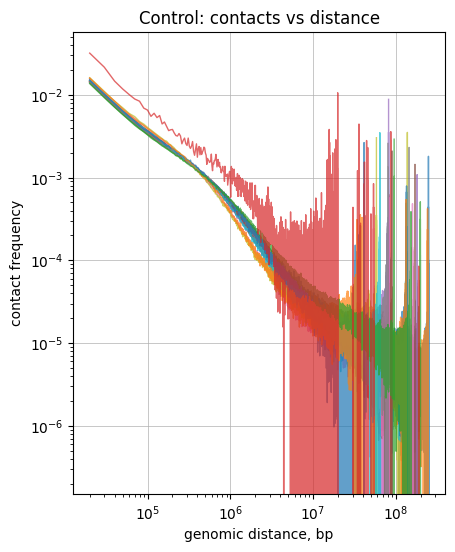

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))

for region in view_df['name']:
    region_data = cvd[
        (cvd['region1'] == region) &
        (cvd['region2'] == region) &
        (cvd['dist_bp'] > 0)
    ]

    ax.loglog(
        region_data['dist_bp'],
        region_data[value_col],
        linewidth=1,
        alpha=0.7
    )

ax.set(
    xlabel='genomic distance, bp',
    ylabel='contact frequency',
    title=f'{sample}: contacts vs distance'
)

ax.grid(linewidth=0.5)
ax.set_aspect(1.0)

plt.show()


## 7. Сглаженная P(s) кривая

Без сглаживания кривые могут быть шумными, особенно на больших расстояниях.

Поэтому `cooltools.expected_cis` умеет сглаживать P(s) и агрегировать результат между регионами.  
Для этого используем:

- `smooth=True`
- `aggregate_smoothed=True`
- `smooth_sigma=0.1`


In [8]:
cvd_smooth = cooltools.expected_cis(
    clr=clr,
    view_df=view_df,
    smooth=True,
    aggregate_smoothed=True,
    smooth_sigma=0.1,
    clr_weight_name=weight_name,
    nproc=16
)

cvd_smooth.head()


INFO:root:creating a Pool of 16 workers


,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg,balanced.avg.smoothed,balanced.avg.smoothed.agg
0,1,1,0,0,NaN,24896,21354,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,1,10000,0.000156,24895,21190,NaN,NaN,NaN,NaN,0.000159,0.000156
2,1,1,2,20000,0.013641,24894,21148,173860.0,316.730143,6.984012,0.014977,0.013957,0.013641
3,1,1,3,30000,0.009649,24893,21119,117952.0,215.006487,4.738360,0.010181,0.009906,0.009649
4,1,1,4,40000,0.007385,24892,21091,89710.0,163.104457,3.603969,0.007733,0.007587,0.007385


## 8. Рисуем сглаженную агрегированную кривую

Колонка `balanced.avg.smoothed.agg` содержит сглаженную кривую, усреднённую между регионами.

Если данные не были сбалансированы, используем аналогичную колонку для raw counts.


In [9]:
if 'balanced.avg.smoothed.agg' in cvd_smooth.columns and cvd_smooth['balanced.avg.smoothed.agg'].notna().any():
    smooth_col = 'balanced.avg.smoothed.agg'
elif 'count.avg.smoothed.agg' in cvd_smooth.columns:
    smooth_col = 'count.avg.smoothed.agg'
else:
    smooth_col = value_col

print('Column for smoothed plotting:', smooth_col)

cvd_merged = (
    cvd_smooth
    .drop_duplicates(subset=['dist'])
    [['dist', 'dist_bp', smooth_col]]
    .copy()
)

cvd_merged.loc[cvd_merged['dist'] < 2, smooth_col] = np.nan
cvd_merged = cvd_merged.dropna(subset=[smooth_col])
cvd_merged.head()


Column for smoothed plotting: balanced.avg.smoothed.agg


,dist,dist_bp,balanced.avg.smoothed.agg
2,2,20000,0.013641
3,3,30000,0.009649
4,4,40000,0.007385
5,5,50000,0.006049
6,6,60000,0.005178


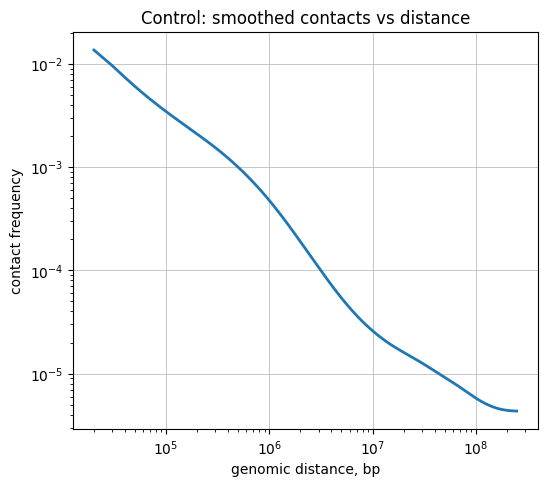

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.loglog(
    cvd_merged['dist_bp'],
    cvd_merged[smooth_col],
    linewidth=2
)

ax.set(
    xlabel='genomic distance, bp',
    ylabel='contact frequency',
    title=f'{sample}: smoothed contacts vs distance'
)

ax.grid(linewidth=0.5)
ax.set_aspect(1.0)

plt.show()


## 9. Производная P(s)

Производная в log-log пространстве показывает, насколько быстро падает контактная частота с расстоянием


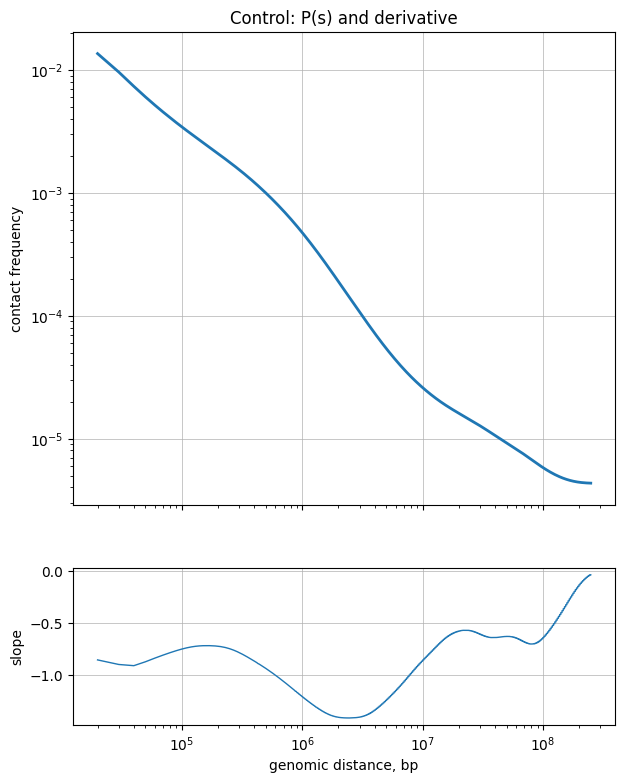

In [11]:
derivative = np.gradient(
    np.log(cvd_merged[smooth_col]),
    np.log(cvd_merged['dist_bp'])
)

fig, axs = plt.subplots(
    nrows=2,
    figsize=(7, 9),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

axs[0].loglog(
    cvd_merged['dist_bp'],
    cvd_merged[smooth_col],
    linewidth=2
)

axs[0].set(
    ylabel='contact frequency',
    title=f'{sample}: P(s) and derivative'
)
axs[0].grid(linewidth=0.5)

axs[1].semilogx(
    cvd_merged['dist_bp'],
    derivative,
    linewidth=1
)

axs[1].set(
    xlabel='genomic distance, bp',
    ylabel='slope'
)
axs[1].grid(linewidth=0.5)

plt.show()


## 10. Считаем P(s) для трёх образцов

Теперь повторим расчёт для `Control`, `Treated` и `Prime`.

Для каждого образца сохраним сглаженную агрегированную P(s) кривую в одну таблицу.


In [12]:
all_cvd = []

for sample, clr in clrs.items():
    print(f'Processing {sample}...')

    weight_name = 'weight' if 'weight' in clr.bins().columns else None

    cvd_sample = cooltools.expected_cis(
        clr=clr,
        view_df=view_df,
        smooth=True,
        aggregate_smoothed=True,
        smooth_sigma=0.1,
        clr_weight_name=weight_name,
        nproc=4
    )

    if 'balanced.avg.smoothed.agg' in cvd_sample.columns and cvd_sample['balanced.avg.smoothed.agg'].notna().any():
        sample_col = 'balanced.avg.smoothed.agg'
    elif 'count.avg.smoothed.agg' in cvd_sample.columns:
        sample_col = 'count.avg.smoothed.agg'
    else:
        sample_col = 'count.avg'

    merged = (
        cvd_sample
        .drop_duplicates(subset=['dist'])
        [['dist', 'dist_bp', sample_col]]
        .rename(columns={sample_col: 'contact_frequency'})
        .copy()
    )

    merged['sample'] = sample
    merged.loc[merged['dist'] < 2, 'contact_frequency'] = np.nan

    all_cvd.append(merged)

all_cvd_df = pd.concat(all_cvd, ignore_index=True)
all_cvd_df.head()


INFO:root:creating a Pool of 4 workers


Processing Control...


INFO:root:creating a Pool of 4 workers


Processing Treated...


INFO:root:creating a Pool of 4 workers


Processing Prime...


,dist,dist_bp,contact_frequency,sample
0,0,0,NaN,Control
1,1,10000,NaN,Control
2,2,20000,0.013641,Control
3,3,30000,0.009649,Control
4,4,40000,0.007385,Control


## 11. Сравниваем Contacts vs distance между образцами

На этом графике каждая линия — один образец.

Если линии отличаются, это может отражать различия в глобальной организации хроматина, качестве библиотеки, глубине секвенирования или нормализации.


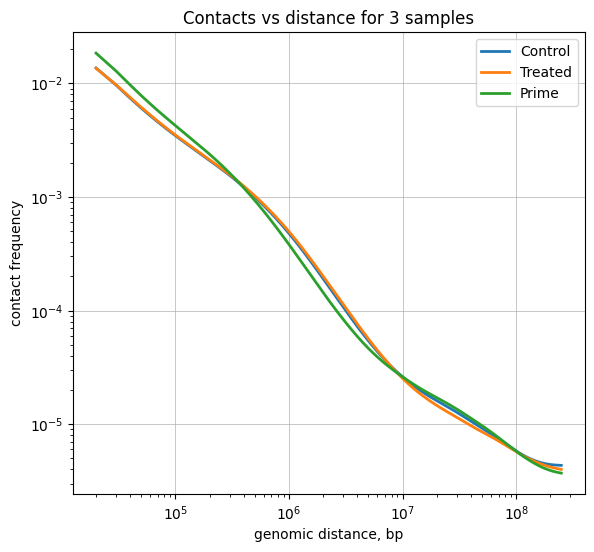

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))

for sample in sample_names:
    data = all_cvd_df[
        (all_cvd_df['sample'] == sample) &
        (all_cvd_df['contact_frequency'].notna()) &
        (all_cvd_df['dist_bp'] > 0)
    ]

    ax.loglog(
        data['dist_bp'],
        data['contact_frequency'],
        linewidth=2,
        label=sample
    )

ax.set(
    xlabel='genomic distance, bp',
    ylabel='contact frequency',
    title='Contacts vs distance for 3 samples'
)

ax.grid(linewidth=0.5)
ax.legend()
ax.set_aspect(1.0)

plt.show()


## 12. Производные для трех образцов

Теперь сравним не только сами P(s) кривые, но и их наклон.

Наклон показывает, как быстро контактная частота падает с увеличением геномного расстояния.


In [14]:
derivatives = []

for sample in sample_names:
    data = (
        all_cvd_df[
            (all_cvd_df['sample'] == sample) &
            (all_cvd_df['contact_frequency'].notna()) &
            (all_cvd_df['dist_bp'] > 0)
        ]
        .sort_values('dist_bp')
        .copy()
    )

    data['slope'] = np.gradient(
        np.log(data['contact_frequency']),
        np.log(data['dist_bp'])
    )

    derivatives.append(data)

derivatives_df = pd.concat(derivatives, ignore_index=True)
derivatives_df.head()


,dist,dist_bp,contact_frequency,sample,slope
0,2,20000,0.013641,Control,-0.854007
1,3,30000,0.009649,Control,-0.898014
2,4,40000,0.007385,Control,-0.909579
3,5,50000,0.006049,Control,-0.871794
4,6,60000,0.005178,Control,-0.836101


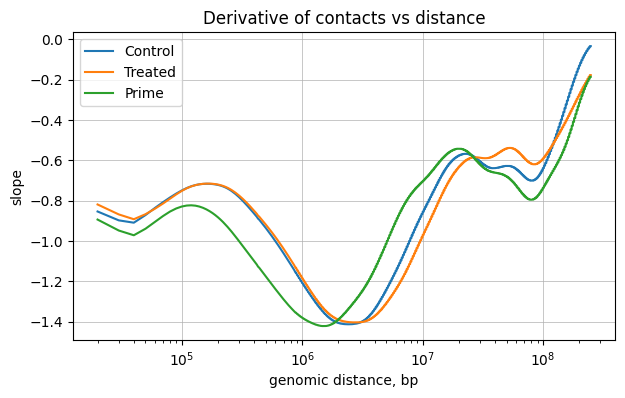

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))

for sample in sample_names:
    data = derivatives_df[derivatives_df['sample'] == sample]

    ax.semilogx(
        data['dist_bp'],
        data['slope'],
        linewidth=1.5,
        label=sample
    )

ax.set(
    xlabel='genomic distance, bp',
    ylabel='slope',
    title='Derivative of contacts vs distance'
)

ax.grid(linewidth=0.5)
ax.legend()

plt.show()
